---
title: "Lab 7"
format: 
    html:
        embed-resources: true
code-fold: true
echo: true
---

## Part 1 - Fitting Models

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, precision_recall_curve
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [ ]:
ha = pd.read_csv("https://www.dropbox.com/s/aohbr6yb9ifmc8w/heart_attack.csv?dl=1")
ha.head()

,age,sex,cp,trtbps,chol,restecg,thalach,output
0,63,1,3,145,233,0,150,1
1,37,1,2,130,250,1,187,1
2,56,1,1,120,236,1,178,1
3,57,0,0,120,354,1,163,1
4,57,1,0,140,192,1,148,1


In [ ]:
ha.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      273 non-null    int64
 1   sex      273 non-null    int64
 2   cp       273 non-null    int64
 3   trtbps   273 non-null    int64
 4   chol     273 non-null    int64
 5   restecg  273 non-null    int64
 6   thalach  273 non-null    int64
 7   output   273 non-null    int64
dtypes: int64(8)
memory usage: 17.2 KB


In [ ]:
ct = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore', drop="first"),
    make_column_selector(dtype_include=object)),
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

Q1: KNN Model

In [ ]:
X = ha.drop(columns = "output")
y = ha["output"]

knn_pipeline = Pipeline(
  [("preprocessing", ct),
  ("knn_regressor", KNeighborsClassifier())
  ]
)
param_grid = {
  "knn_regressor__n_neighbors": [1,2,3,4,5,6,7,8,9,10]
}
gscv1 = GridSearchCV(knn_pipeline, param_grid=param_grid, cv = 5, scoring='roc_auc')

In [ ]:
gscv1_fit = gscv1.fit(X, y)
gscv1_fit

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('dummify',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b3b4b465eb0>),
                                                                        ('standardize',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b3b4b465e20>)])),
                                       ('knn_regressor',
                                        KNeighborsClassifier())]),
             param_grid={'knn_regressor__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8,
                                                        9, 10]},
             scoring='roc_auc')

In [ ]:
df_cv_results_1 = pd.DataFrame(gscv1_fit.cv_results_)

df_cv_results_1.sort_values(by="rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn_regressor__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,0.005979,0.000481,0.005302,0.000399,6,{'knn_regressor__n_neighbors': 6},0.812000,0.795093,0.854111,0.904828,0.723448,0.817896,0.060570,1
4,0.005526,0.000330,0.005258,0.000493,5,{'knn_regressor__n_neighbors': 5},0.787333,0.810345,0.850796,0.888276,0.733793,0.814109,0.052969,2
7,0.005693,0.000241,0.005273,0.000295,8,{'knn_regressor__n_neighbors': 8},0.834667,0.772546,0.829576,0.909655,0.717241,0.812737,0.064641,3
9,0.006049,0.000197,0.005396,0.000198,10,{'knn_regressor__n_neighbors': 10},0.841333,0.772546,0.838859,0.911034,0.690345,0.810824,0.074484,4
6,0.006392,0.000359,0.005925,0.000658,7,{'knn_regressor__n_neighbors': 7},0.822000,0.795093,0.824271,0.901379,0.708966,0.810342,0.061851,5


K value of 6 looks to be the best model.

In [ ]:
testPredictionProbs = gscv1_fit.predict_proba(X)
auc_value = roc_auc_score(y, testPredictionProbs[:, 1], multi_class='ovr', average='weighted')
print("Test AUC:", auc_value)

Test AUC: 0.9056466400604033


In [ ]:
y_train_1 = pd.Series(gscv1_fit.predict(X), name = "Predicted")

confusion_matrix(y, y_train_1)

array([[107,  20],
       [ 37, 109]])

Q2: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
X = ha.drop(columns = "output")
y = ha["output"]

logreg_pipeline = Pipeline(
  [("preprocessing", ct),
  ("logreg", LogisticRegression(max_iter=1000, solver='liblinear'))]
)

param_grid2 = {
  'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
  'logreg__solver': ['liblinear', 'lbfgs']
}

gscv2 = GridSearchCV(logreg_pipeline, param_grid=param_grid2, cv=5, scoring='roc_auc')

In [ ]:
gscv2_fit = gscv2.fit(X, y)
gscv2_fit

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('dummify',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b3b4b465eb0>),
                                                                        ('standardize',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b3b4b465e20>)])),
                                       ('logreg',
                                        LogisticRegression(max_iter=1000,
                                                           solver='liblinear'))]),
             param_grid={'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'logreg__solver': ['liblinear', 'lbfgs']},
             scoring='roc_auc')

In [ ]:
df_cv_results_2 = pd.DataFrame(gscv2_fit.cv_results_)

df_cv_results_2.sort_values(by="rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logreg__C,param_logreg__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.009195,0.000552,0.006063,0.000396,0.01,lbfgs,"{'logreg__C': 0.01, 'logreg__solver': 'lbfgs'}",0.841333,0.899204,0.889920,0.891034,0.751724,0.854643,0.055361,1
2,0.008156,0.000138,0.006275,0.000029,0.01,liblinear,"{'logreg__C': 0.01, 'logreg__solver': 'libline...",0.841333,0.899204,0.889920,0.891034,0.751724,0.854643,0.055361,1
6,0.011609,0.002541,0.010704,0.003047,1.00,liblinear,"{'logreg__C': 1, 'logreg__solver': 'liblinear'}",0.829333,0.885942,0.905836,0.891034,0.754483,0.853326,0.055837,3
7,0.031830,0.007542,0.015793,0.002673,1.00,lbfgs,"{'logreg__C': 1, 'logreg__solver': 'lbfgs'}",0.829333,0.885942,0.905836,0.891034,0.754483,0.853326,0.055837,3
5,0.010178,0.000841,0.006684,0.000413,0.10,lbfgs,"{'logreg__C': 0.1, 'logreg__solver': 'lbfgs'}",0.838667,0.887268,0.896552,0.889655,0.754483,0.853325,0.053526,5


It looks like the best model is one where the param_logreg__C has a value of 0.01 and the param_logreg__solver is either lbfgs or liblinear.

In [ ]:
testPredictionProbs2 = gscv2_fit.predict_proba(X)
auc_value2 = roc_auc_score(y, testPredictionProbs2[:, 1], multi_class='ovr', average='weighted')
print("Test AUC:", auc_value2)

Test AUC: 0.864308057383238


In [ ]:
y_train_2 = gscv2_fit.predict(X)
print(confusion_matrix(y, y_train_2))

[[ 97  30]
 [ 27 119]]


Q3: Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

X = ha.drop(columns = "output")
y = ha["output"]

dt_pipeline = Pipeline(
  [("preprocessing", ct),
  ("decision_tree", DecisionTreeClassifier())
  ]
)
param_grid3 = {
    'decision_tree__max_depth': [None, 5, 10, 15, 20],
    'decision_tree__min_samples_split': [2, 5, 10],
    'decision_tree__min_samples_leaf': [1, 2, 4],
    'decision_tree__criterion': ['gini', 'entropy']
}
gscv3 = GridSearchCV(dt_pipeline, param_grid=param_grid3, cv=5, scoring='roc_auc')

In [ ]:
gscv3_fit = gscv3.fit(X, y)
gscv3_fit

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('dummify',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b3b4b465eb0>),
                                                                        ('standardize',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b3b4b465e20>)])),
                                       ('decision_tree',
                                        DecisionTreeClassifier())]),
             param_grid={'decision_tree__criterion': ['gini', 'entropy'],
                         'decision_tree__max_depth': [None, 5, 10, 15, 20],
                         'decision_tree__min_samples_leaf': [1, 2, 4],
                         'decision_tree__min_samples_split': [2, 5, 10]},
             scoring='roc_auc')

In [ ]:
df_cv_results_3 = pd.DataFrame(gscv3_fit.cv_results_)

df_cv_results_3.sort_values(by="rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decision_tree__criterion,param_decision_tree__max_depth,param_decision_tree__min_samples_leaf,param_decision_tree__min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
62,0.006223,0.000429,0.004356,0.000137,entropy,5,4,10,"{'decision_tree__criterion': 'entropy', 'decis...",0.788000,0.739390,0.793767,0.807586,0.704138,0.766576,0.038776,1
8,0.010701,0.000715,0.008521,0.001900,gini,None,4,10,"{'decision_tree__criterion': 'gini', 'decision...",0.744667,0.769231,0.800398,0.773103,0.744828,0.766445,0.020720,2
61,0.005997,0.000127,0.004235,0.000080,entropy,5,4,5,"{'decision_tree__criterion': 'entropy', 'decis...",0.799333,0.727454,0.792440,0.807586,0.697241,0.764811,0.044150,3
80,0.008338,0.002090,0.005636,0.001416,entropy,15,4,10,"{'decision_tree__criterion': 'entropy', 'decis...",0.825333,0.752653,0.750663,0.782759,0.708276,0.763937,0.038796,4
16,0.005848,0.000101,0.004312,0.000072,gini,5,4,5,"{'decision_tree__criterion': 'gini', 'decision...",0.736667,0.767241,0.795093,0.800690,0.716552,0.763248,0.032616,5


In [ ]:
testPredictionProbs3 = gscv3_fit.predict_proba(X)
auc_value3 = roc_auc_score(y, testPredictionProbs3[:, 1], multi_class='ovr', average='weighted')
print("Test AUC:", auc_value3)

Test AUC: 0.9378707798511488


In [ ]:
y_train_3 = gscv3_fit.predict(X)
print(confusion_matrix(y, y_train_3))

[[112  15]
 [ 21 125]]


The best decision tree model is one with entropy as the criterion, max depth of none, min sample leaf of 4, and min samples split of 5.

Q4: Interpretation

The predictors that seemed most important in predicting heart attack risk were age, sex, cp, and trtbps since they made up a majority of the ROC AUC value (between 0.8 and 0.9). When I tried manually inputting variables into the models to test how different combinations affected the ROC AUC, I consistently found that these variables returned the higher ROC AUC. This makes sense considering that we would expect these predictors to have a huge impact on heart attack risk. Thinks like a person's age, sex, chest pain symptoms, and blood pressure are all things that are directly correlated with heart health. However, when I used all of the variables in the dataset, I got the best values for ROC AUC across all three of the models.

Q5: ROC Curves

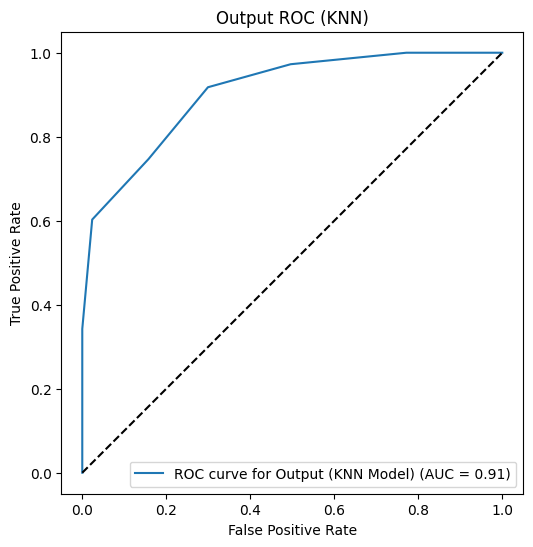

In [ ]:
#KNN ROC
import matplotlib.pyplot as plt

classes = gscv1_fit.best_estimator_.named_steps['knn_regressor'].classes_
positive_class_idx = list(classes).index(1)

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y,
    testPredictionProbs[:, positive_class_idx],
    name=f"ROC curve for Output (KNN Model)",
    ax=plt.gca()
)
plt.title("Output ROC (KNN)")
plt.plot([0, 1], [0, 1], "k--")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

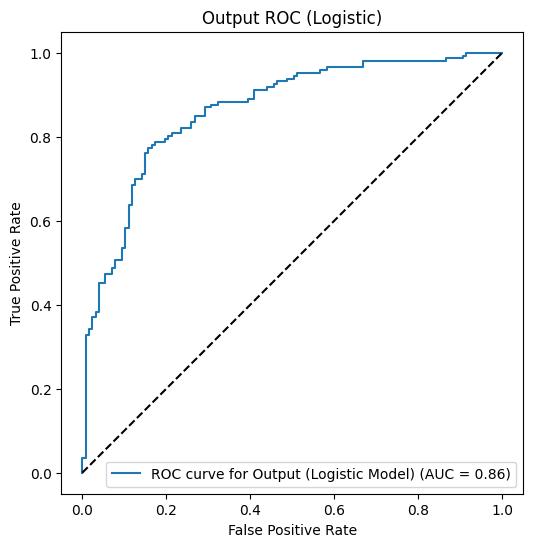

In [ ]:
# Logistic ROC
import matplotlib.pyplot as plt

classes = gscv2_fit.best_estimator_.named_steps['logreg'].classes_
positive_class_idx = list(classes).index(1)

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y,
    testPredictionProbs2[:, positive_class_idx],
    name=f"ROC curve for Output (Logistic Model)",
    ax=plt.gca()
)
plt.title("Output ROC (Logistic)")
plt.plot([0, 1], [0, 1], "k--")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

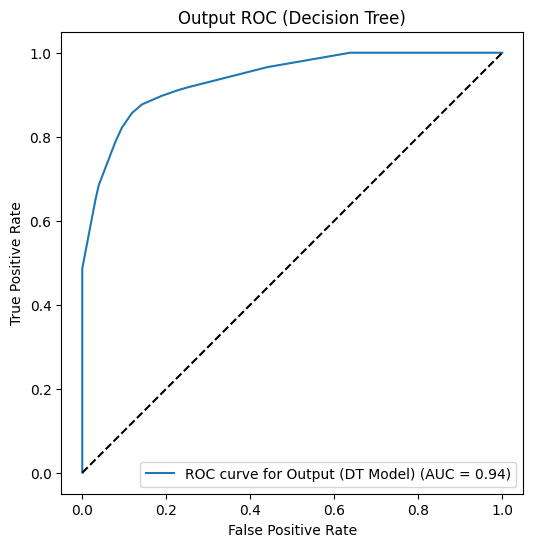

In [ ]:
# Decision Tree ROC
import matplotlib.pyplot as plt

classes = gscv3_fit.best_estimator_.named_steps['decision_tree'].classes_
positive_class_idx = list(classes).index(1)

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y,
    testPredictionProbs3[:, positive_class_idx],
    name=f"ROC curve for Output (DT Model)",
    ax=plt.gca()
)
plt.title("Output ROC (Decision Tree)")
plt.plot([0, 1], [0, 1], "k--")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Part 2: Metrics

In [ ]:
# Metrics for KNN Model
from sklearn.metrics import classification_report
print(classification_report(y, y_train_1, digits=4))

              precision    recall  f1-score   support

           0     0.7431    0.8425    0.7897       127
           1     0.8450    0.7466    0.7927       146

    accuracy                         0.7912       273
   macro avg     0.7940    0.7945    0.7912       273
weighted avg     0.7976    0.7912    0.7913       273



KNN Recall: 0.7466

KNN Precision: 0.8450

KNN Specificity: 0.8425

In [ ]:
# Metrics for the Logistic Regression Model
print(classification_report(y, y_train_2, digits=4))

              precision    recall  f1-score   support

           0     0.7823    0.7638    0.7729       127
           1     0.7987    0.8151    0.8068       146

    accuracy                         0.7912       273
   macro avg     0.7905    0.7894    0.7898       273
weighted avg     0.7910    0.7912    0.7910       273



Logistic Recall: 0.8151

Logistic Precision: 0.7987

Logistic Specificity: 0.7638

In [ ]:
# Metrics for the Decision Tree Model
print(classification_report(y, y_train_3, digits=4))

              precision    recall  f1-score   support

           0     0.8421    0.8819    0.8615       127
           1     0.8929    0.8562    0.8741       146

    accuracy                         0.8681       273
   macro avg     0.8675    0.8690    0.8678       273
weighted avg     0.8692    0.8681    0.8683       273



DT Recall: 0.8699

DT Precision: 0.9203

DT Specificity: 0.9134

## Part 3: Discussion

Q1

In this scenario, a false negative would be costly for the hospital. The metric we should use for this is recall which measures how many actual high-risk patients are identified correctly. We would use the logistic regression model since it gives us probabilities, allowing us to adjust the decision threshold and classify more or less cases as low-risk. Based on our recall scores, the expected recall should be around 0.8 to 0.85 on future data.

Q2

In this scenario, we need to avoid false positives. The appropriate metric for this would be the precision, which is the proportion of patients that are high-risk and actually are. The KNN model would be what I recommend to the hospital since we can tune the hyperparameters to get a more conservative model. Based on our precision scores, the precision should be about 0.8 to 0.9 on future data.

Q3

In this scenario, we would use the accuracy score to get the best model overall. The model that we should use is a decision tree so we can see what exactly leads to heart attacks. It would be especially easy to see it if we plot the decision tree. Based on our accuracy score for the decision tree model, we would expect the accuracy score to be around 0.9 for future data.

Q4

In this scenario, we should use the accuracy score to compare it to the doctor's predictions. I would also recommend the decision tree model for this situation as well, since it gives a visual that can be compared to the doctor's reasoning and prediction. Based off the accuracy score for our decision tree model, we would expect the accuracy score to be around 0.9 for future data.

## Part 4: Validation

In [ ]:
ha_validation = pd.read_csv("https://www.dropbox.com/s/jkwqdiyx6o6oad0/heart_attack_validation.csv?dl=1")
X_val = ha_validation.drop(columns="output")
y_val = ha_validation["output"]

KNN

In [ ]:
y_pred_knn = gscv1_fit.predict(X_val)

classes_knn = gscv1_fit.best_estimator_.named_steps['knn_regressor'].classes_
pos_idx_knn = list(classes_knn).index(1)
y_proba_knn = gscv1_fit.predict_proba(X_val)[:, pos_idx_knn]

In [ ]:
cm_knn = confusion_matrix(y_val, y_pred_knn, labels=[0, 1])
print(cm_knn)

[[10  1]
 [ 9 10]]


In [ ]:
auc_knn = roc_auc_score(y_val, y_proba_knn)
prec_knn = precision_score(y_val, y_pred_knn, zero_division=0)
rec_knn = recall_score(y_val, y_pred_knn, zero_division=0)
print("AUC:",auc_knn)
print("Precision",prec_knn)
print("Recall:",rec_knn)

AUC: 0.839712918660287
Precision 0.9090909090909091
Recall: 0.5263157894736842


Logistic

In [ ]:
y_pred_log = gscv2_fit.predict(X_val)

classes_log = gscv2_fit.best_estimator_.named_steps['logreg'].classes_
pos_idx_log = list(classes_log).index(1)
y_proba_log = gscv2_fit.predict_proba(X_val)[:, pos_idx_log]

In [ ]:
cm_log = confusion_matrix(y_val, y_pred_log, labels=[0, 1])
print(cm_log)

[[10  1]
 [ 4 15]]


In [ ]:
auc_log = roc_auc_score(y_val, y_proba_log)
prec_log = precision_score(y_val, y_pred_log, zero_division=0)
rec_log = recall_score(y_val, y_pred_log, zero_division=0)
print("AUC:",auc_log)
print("Precision",prec_log)
print("Recall:",rec_log)

AUC: 0.937799043062201
Precision 0.9375
Recall: 0.7894736842105263


Decision Tree

In [ ]:
y_pred_dt = gscv3_fit.predict(X_val)

classes_dt = gscv3_fit.best_estimator_.named_steps['decision_tree'].classes_
pos_idx_dt = list(classes_dt).index(1)
y_proba_dt = gscv3_fit.predict_proba(X_val)[:, pos_idx_dt]

In [ ]:
cm_dt = confusion_matrix(y_val, y_pred_dt, labels=[0, 1])
print(cm_dt)

[[ 8  3]
 [ 7 12]]


In [ ]:
auc_dt = roc_auc_score(y_val, y_proba_dt)
prec_dt = precision_score(y_val, y_pred_dt, zero_division=0)
rec_dt = recall_score(y_val, y_pred_dt, zero_division=0)
print("AUC:",auc_dt)
print("Precision",prec_dt)
print("Recall:",rec_dt)

AUC: 0.8349282296650719
Precision 0.8
Recall: 0.631578947368421


For both my KNN model and my decision tree model, the precision and recall for the validation set are both comparable to the metrics we got for the model, since precision is higher than recall for both. With the logistic regression model, the precision was higher than the recall but on the first set of data the recall was higher than the precision. The ROC AUC score decreases for both KNN and decision tree, but increased for the logistic model. Our measure of model success seems to be sort of correct.

## Part 5: Cohen's Kappa

In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa_knn = cohen_kappa_score(y_val, y_pred_knn)
kappa_log = cohen_kappa_score(y_val, y_pred_log)
kappa_dt  = cohen_kappa_score(y_val, y_pred_dt)
print("KNN Kappa:", kappa_knn)
print("Logistic Kappa:", kappa_log)
print("DT Kappa:", kappa_dt)

KNN Kappa: 0.3775933609958506
Logistic Kappa: 0.660633484162896
DT Kappa: 0.33333333333333337


A possible scenario in which we would use this metric as our measure of model success could be in the 4th scenario from part 3 of this lab. Cohen's Kappa could be used to measure the agreement between the model and the doctors beyond just random chance. Yes my conclusion from above does change because now it looks like the logistic model is the model that performs the best compared to random guessing. Yes this makes sense because metrics like precision, recall, and AUC measures the overall performance of the model while Cohen's Kappa adjusts for the possibility that we just got lucky that the outcomes agreed. A Cohen's Kappa score of 0.66 means that there is substantial agreement between our model predictions and the actual values, meaning that our decision tree model has good performance.